# Important!
When initially opening the notebook there should be a text to the right of the "Help" menu saying "Changes will not be saved".
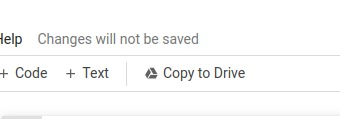

To ensure you can make changes to the notebook save a copy of it to your own drive and work on that one. You can do that by going to "File" -> "Save a copy in Drive".

**Failing to do so will result in code loss!**

 **Note** Make sure you are the only one that has access to it!


# Setup

In [3]:
#@markdown **NOTE**: It is strongly advised you save your results to Google
#@markdown Drive as they will be deleted from Colab once it restarts.
#@markdown To connect Google Drive run this cell, login to your account, and approve all the requested permissions.
from google.colab import drive
drive.mount('/content/gdrive/')

ROOT_GDRIVE_PATH="/content/gdrive/MyDrive/"
GDRIVE_SAVE_REL_PATH = "IMPR_Ex5"
FULL_GDRIVE_SAVE_PATH = ROOT_GDRIVE_PATH + GDRIVE_SAVE_REL_PATH

print(f'Mounted Google Drive, code and results will be saved to the "{GDRIVE_SAVE_REL_PATH}" dir...')


Mounted at /content/gdrive/
Mounted Google Drive, code and results will be saved to the "IMPR_Ex5" dir...


In [4]:
#@markdown #Image Processing - 67829. { display-mode: "form" }
#@markdown ##Exercise 5
#@markdown ##Due date: 22.01.2026 at 23:59
#@title{ display-mode: "form" }

#@markdown
#@markdown This exercise is a bit different than the rest of the exercises in the course.
#@markdown The submissions will be a PDF file with your answers and results to the exercise.
#@markdown This notebook provides the basic code, but you do not need to adhere to some specific API
#@markdown and we will not be running unit tests on your code.
#@markdown We will however, be going over your code and running it manually.
#@markdown Moreover, we will be running tests to ensure the authenticity of your solution and detect plagiarism.
#@markdown
#@markdown
#@markdown Before you start working on the exercise it is recommended that you review the lecture slides covering neural networks.
#@markdown
#@markdown
#@markdown **NOTE**: Neural networks are typically trained on GPUs, without GPUs training takes much longer.
#@markdown To enable GPU tranining click on "Runtime" -> "Change runtime type" -> "GPU" -> "SAVE".
#@markdown
#@markdown **NOTE**: A short guide on debugging your code using colab is availble [here](https://colab.research.google.com/github/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/01.06-Errors-and-Debugging.ipynb#scrollTo=qnIn-rWFqoww).

#@markdown But first, we have to download all of the dependencies and install them.
#@markdown Play this cell to download it and get everything ready. markdown This may take a few minutes.

# Install dependencies.
!pip install bitsandbytes transformers accelerate peft -q
!pip install git+https://github.com/huggingface/diffusers.git -q
!pip install datasets -q

import os
import locale
import re
import glob
from PIL import Image
from diffusers import DiffusionPipeline
import torch
from diffusers import StableDiffusionImg2ImgPipeline
from diffusers.utils import load_image


locale.getpreferredencoding = lambda: "UTF-8"

!accelerate config default

# Only download train_dreambooth_lora.py if it doesn't exist
if not os.path.exists('train_dreambooth_lora.py'):
    !wget https://raw.githubusercontent.com/huggingface/diffusers/main/examples/dreambooth/train_dreambooth_lora.py
else:
    print("train_dreambooth_lora.py already exists, skipping download.")

# Set Hugging Face cache to Google Drive
HF_CACHE_DIR = f"{FULL_GDRIVE_SAVE_PATH}/huggingface_cache"
os.makedirs(HF_CACHE_DIR, exist_ok=True)

# Set environment variables
os.environ['HF_HOME'] = HF_CACHE_DIR
os.environ['HUGGINGFACE_HUB_CACHE'] = HF_CACHE_DIR
os.environ['TRANSFORMERS_CACHE'] = HF_CACHE_DIR

print(f"✅ Hugging Face cache set to: {HF_CACHE_DIR}")


# Updating training script to save validation outputs locally

file_path = 'train_dreambooth_lora.py'

with open(file_path, 'r') as f:
    content = f.read()

# --- 1. Fix the log_validation function to handle 'step' and save to disk ---
# We replace the tracker loop logic to save to disk using the 'epoch' variable
# which we will now treat as the 'step' variable.
old_tracker_block = r'    for tracker in accelerator.trackers:.*?(?=    del pipeline)'
new_tracker_block = '''    # --- DISK SAVING PATCH ---
    if accelerator.is_main_process:
        val_save_dir = os.path.join(args.output_dir, "validation_images")
        os.makedirs(val_save_dir, exist_ok=True)
        label = "final" if is_final_validation else f"step_{epoch}"
        for i, image in enumerate(images):
            image.save(os.path.join(val_save_dir, f"{label}_img_{i}.png"))
        logger.info(f"✅ Saved validation images for {label}")
    # --------------------------
    for tracker in accelerator.trackers:'''

content = re.sub(old_tracker_block, new_tracker_block, content, flags=re.DOTALL)

# --- 2. Move Validation Trigger from Epoch Loop to Step Loop ---
# First, we remove the old validation block that triggers at the end of epochs
epoch_val_pattern = r'        if accelerator\.is_main_process:\n            if args\.validation_prompt is not None and epoch % args\.validation_epochs == 0:.*?log_validation\(.*?weight_dtype=weight_dtype,\n                \)'
content = re.sub(epoch_val_pattern, '', content, flags=re.DOTALL)

# Now, we insert a NEW trigger inside the step loop, right where checkpoints are saved.
# We look for the checkpoint saving logic as our anchor.
checkpoint_anchor = '                        accelerator.save_state(save_path)\n                        logger.info(f"Saved state to {save_path}")'
validation_trigger = '''                        accelerator.save_state(save_path)
                        logger.info(f"Saved state to {save_path}")

                        # --- NEW VALIDATION TRIGGER (Step-based) ---
                        if args.validation_prompt is not None:
                            logger.info(f"Running validation at step {global_step}...")
                            pipeline = DiffusionPipeline.from_pretrained(
                                args.pretrained_model_name_or_path,
                                unet=unwrap_model(unet),
                                text_encoder=None if args.pre_compute_text_embeddings else unwrap_model(text_encoder),
                                revision=args.revision,
                                variant=args.variant,
                                torch_dtype=weight_dtype,
                            )
                            p_args = {"prompt": args.validation_prompt} if not args.pre_compute_text_embeddings else {
                                "prompt_embeds": validation_prompt_encoder_hidden_states,
                                "negative_prompt_embeds": validation_prompt_negative_prompt_embeds,
                            }
                            log_validation(pipeline, args, accelerator, p_args, global_step, weight_dtype)'''

content = content.replace(checkpoint_anchor, validation_trigger)

# --- 3. Fix DreamBoothDataset to only load image files and exclude directories ---
# Define the pattern that matches the original two lines
old_instance_images_full_block = r"""        self.instance_images_path = list(Path\(instance_data_root\)\.iterdir\(\))\n        self.num_instance_images = len\(self.instance_images_path\)"""

# Define the full replacement block including the num_instance_images check
new_instance_images_block = r"""        self.instance_images_path = []
        for ext in ["*.png", "*.jpg", "*.jpeg", "*.JPG", "*.PNG"]:
            self.instance_images_path.extend(glob.glob(os.path.join(instance_data_root, ext)))
        # Ensure paths point to actual files
        self.instance_images_path = [path for path in self.instance_images_path if os.path.isfile(path)]
        # Sort them to ensure reproducibility
        self.instance_images_path.sort()
        self.num_instance_images = len(self.instance_images_path) # RE-EVALUATE THIS LINE after modification
        if self.num_instance_images == 0:
            raise ValueError(f"No image files found in {instance_data_root} with extensions .png, .jpg, .jpeg, .JPG, .PNG.")
"""

# Perform a single replacement for the entire block
content = re.sub(old_instance_images_full_block, new_instance_images_block, content, flags=re.DOTALL)


with open(file_path, 'w') as f:
    f.write(content)


def image_grid(imgs, rows, cols, resize=256):

    if resize is not None:
        imgs = [img.resize((resize, resize)) for img in imgs]
    w, h = imgs[0].size
    grid = Image.new("RGB", size=(cols * w, rows * h))
    grid_w, grid_h = grid.size

    for i, img in enumerate(imgs):
        grid.paste(img, box=(i % cols * w, i // cols * h))
    return grid

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
accelerate configuration saved at /root/.cache/huggingface/accelerate/default_config.yaml
--2026-02-21 04:01:47--  https://raw.githubusercontent.com/huggingface/diffusers/main/examples/dreambooth/train_dreambooth_lora.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 59191 (58K) [text/plain]
Saving to: ‘train_dreambooth_lora.py’

train_dreambooth_lo 100%[===================>]  57.80K  --.-KB/s    in 0.006s  

2026-02-21 04:01:47 (10.2 MB/s) - ‘train_dreambooth_lora.py’ saved [59191/59191]

✅ Hugging Face cache set to: /content/gdrive/MyDrive/IMPR_

**bold text**# Dataset loading

Saving chow1.jpg to chow1.jpg
Saving chow2.jpg to chow2.jpg
Saving chow3.jpg to chow3.jpg
Saving chow4.jpg to chow4.jpg
Saving chow5.jpg to chow5.jpg
Saving chow6.jpg to chow6.jpg
Saving chow7.jpg to chow7.jpg
Saving chow8.jpg to chow8.jpg
Saving chow9.jpg to chow9.jpg
Saving chow10.jpg to chow10.jpg
Saving chow11.jpg to chow11.jpg
Saving chow12.jpg to chow12.jpg


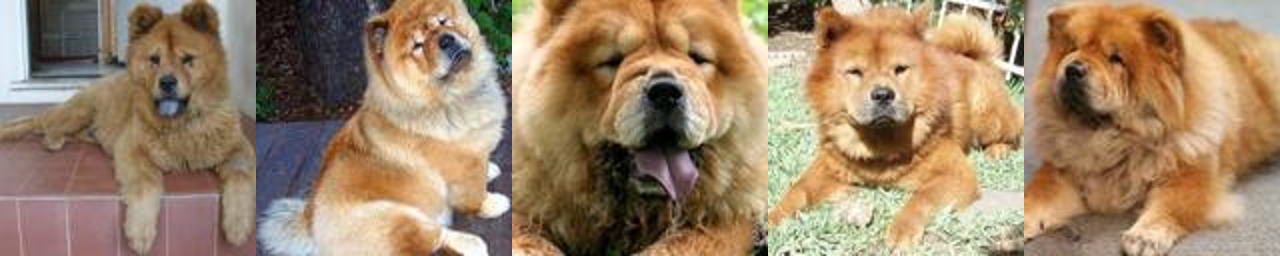

In [ ]:
#@markdown Upload your dataset.
#@markdown
#@markdown **NOTE**: For sanity check you can call the next cell instead and use an example dataset.
import os
from google.colab import files

# pick a name for the image folder
dataset_dir_name = "chow" #@param
dataset_dir = f"{FULL_GDRIVE_SAVE_PATH}/dreambooth_datasets/{dataset_dir_name}"
os.makedirs(dataset_dir, exist_ok=True)
os.chdir(dataset_dir)

# choose and upload local images into the newly created directory
uploaded_images = files.upload()
os.chdir("/content") # back to parent directory


# Display 5 images
extensions = ['*.png', '*.jpg', '*.jpeg', '*.JPG', '*.PNG']
imgs_paths = []

for ext in extensions:
    imgs_paths.extend(glob.glob(f"{dataset_dir}/{ext}"))

# Sort them to keep the order consistent
imgs_paths.sort()

imgs = [Image.open(path) for path in imgs_paths]

num_imgs_to_preview = 5
image_grid(imgs[:num_imgs_to_preview], 1, num_imgs_to_preview)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

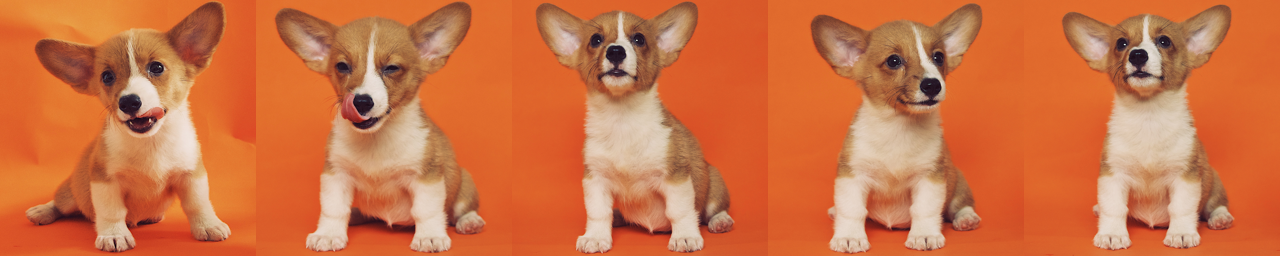

In [ ]:
#@markdown Example dataset for sanity testing
#@markdown
#@markdown **NOTE**: For sanity check you can call the next cell instead and use an example dataset.

from huggingface_hub import snapshot_download


dataset_dir = f"{FULL_GDRIVE_SAVE_PATH}/dreambooth_datasets/example_dog"
os.makedirs(dataset_dir, exist_ok=True)

snapshot_download("diffusers/dog-example", local_dir=dataset_dir, repo_type="dataset", ignore_patterns=".gitattributes",)


# Display 5 images
extensions = ['*.png', '*.jpg', '*.jpeg', '*.JPG', '*.PNG']
imgs_paths = []

for ext in extensions:
    imgs_paths.extend(glob.glob(f"{dataset_dir}/{ext}"))

# Sort them to keep the order consistent
imgs_paths.sort()

imgs = [Image.open(path) for path in imgs_paths]

num_imgs_to_preview = 5
image_grid(imgs[:num_imgs_to_preview], 1, num_imgs_to_preview)

In [ ]:
# Re-define your paths
dataset_dir = "/content/gdrive/MyDrive/IMPR_Ex5/dreambooth_datasets/chow"
FULL_GDRIVE_SAVE_PATH = "/content/gdrive/MyDrive/IMPR_Ex5"

# Safety Check: Does the computer see the checkpoint?
import os
ckpt_path = f"{FULL_GDRIVE_SAVE_PATH}/chow_outputs/checkpoint-700"
if os.path.exists(ckpt_path):
    print(f"✅ Found checkpoint at: {ckpt_path}")
else:
    print(f"❌ Could not find {ckpt_path}. Please check your folder name!")

✅ Found checkpoint at: /content/gdrive/MyDrive/IMPR_Ex5/chow_outputs/checkpoint-700


In [ ]:
# Re-confirm variables
dataset_dir = "/content/gdrive/MyDrive/IMPR_Ex5/dreambooth_datasets/chow"
FULL_GDRIVE_SAVE_PATH = "/content/gdrive/MyDrive/IMPR_Ex5"

import os
# Check for the checkpoint-700 folder inside chow_outputs
ckpt_path = f"{FULL_GDRIVE_SAVE_PATH}/chow_outputs/checkpoint-700"
if os.path.exists(ckpt_path):
    print(f"✅ Found checkpoint at: {ckpt_path}")
else:
    print(f"❌ Cannot find folder! Checked: {ckpt_path}")

✅ Found checkpoint at: /content/gdrive/MyDrive/IMPR_Ex5/chow_outputs/checkpoint-700


# Training DreamBooth

Below is an example of a how to run a training session of DreamBooth.
Important parameters:

- `instance_prompt` - used to describe the training dataset and the unique text token to personalize the concept to (in our case `TOK`).
- `validation_prompt` - used for generating validation images of this prompt during training (need to use the unique token in the prompt).
- `output_dir` - Path to save the results (checkpoints and validation images)
- `max_train_steps` - Number of training steps.
- `checkpointing_steps` - How often to save checkpoints of the model
- `validation_epochs` - How often to run the validation

For more training arguments and training details, see the original training script [here](https://github.com/huggingface/diffusers/blob/main/examples/dreambooth/train_dreambooth_lora.py), and read about it [here](https://github.com/huggingface/diffusers/blob/main/examples/dreambooth/README.md) and [here](https://huggingface.co/docs/diffusers/en/training/dreambooth).

**Note:** Training for 1000 steps can take 15-30 minutes.

In [ ]:
!accelerate launch train_dreambooth_lora.py \
  --pretrained_model_name_or_path="stable-diffusion-v1-5/stable-diffusion-v1-5"  \
  --instance_data_dir="$dataset_dir" \
  --output_dir="$FULL_GDRIVE_SAVE_PATH/chow_outputs" \
  --instance_prompt="a photo of TOK chow" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=1 \
  --checkpointing_steps=50 \
  --learning_rate=1e-4 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --max_train_steps=800 \
  --resume_from_checkpoint="checkpoint-700" \
  --validation_prompt="A photo of TOK chow on a snowy mountain" \
  --validation_epochs=50 \
  --seed="0" \
  --num_validation_images=3

Streaming output truncated to the last 5000 lines.
Loading weights:  42% 166/396 [00:00<00:00, 607.40it/s, Materializing param=vision_model.vision_model.encoder.layers.9.self_attn.v_proj.bias]  

Loading weights:  42% 166/396 [00:00<00:00, 607.40it/s, Materializing param=vision_model.vision_model.encoder.layers.9.self_attn.v_proj.bias]

Loading weights:  42% 167/396 [00:00<00:00, 607.40it/s, Materializing param=vision_model.vision_model.encoder.layers.9.self_attn.v_proj.weight]

Loading weights:  42% 167/396 [00:00<00:00, 607.40it/s, Materializing param=vision_model.vision_model.encoder.layers.9.self_attn.v_proj.weight]

Loading weights:  42% 168/396 [00:00<00:00, 607.40it/s, Materializing param=vision_model.vision_model.encoder.layers.10.layer_norm1.bias]      

Loading weights:  42% 168/396 [00:00<00:00, 607.40it/s, Materializing param=vision_model.vision_model.encoder.layers.10.layer_norm1.bias]

Loading weights:  43% 169/396 [00:00<00:00, 607.40it/s, Materializing param=vision_mode

## Generating Images from Trained DreamBooth

In [ ]:
# Load the trained model
import torch
from diffusers import DiffusionPipeline
pipe = DiffusionPipeline.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5").to("cuda")

lora_checkpoint_path = f"{FULL_GDRIVE_SAVE_PATH}/chow_outputs/checkpoint-400"
pipe.load_lora_weights(lora_checkpoint_path)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/50 [00:00<?, ?it/s]

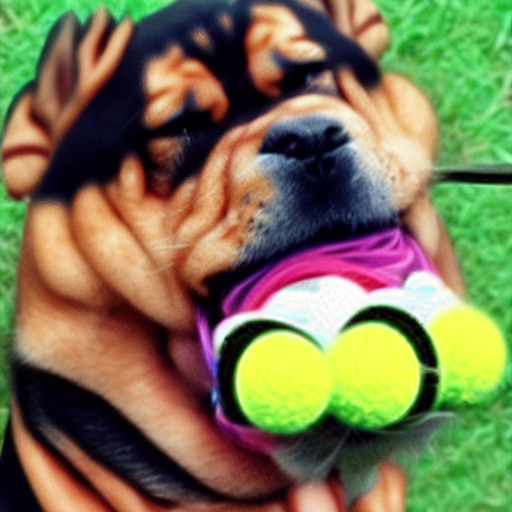

In [ ]:
# Generate an image
prompt = "a photo of TOK chow dog with a single tennis ball in its mouth"
image = pipe(prompt=prompt, num_inference_steps=50).images[0]
display(image)

# Running SDEdit

**Note: If you are getting an `OutOfMemoryError: CUDA out of memory...` error you may need to remove some of the StableDiffusion pipelines from you memory or restart the notebook to get a fresh GPU memory.**

In [ ]:
import torch
import gc

# 1. Delete the pipeline variables
if 'base_pipe' in globals():
    del base_pipe
if 'lora_pipe' in globals():
    del lora_pipe

# 2. Trigger Python's garbage collector
gc.collect()

# 3. Clear the CUDA cache to release memory back to the GPU
torch.cuda.empty_cache()

print("✅ GPU Memory cleared successfully!")

✅ GPU Memory cleared successfully!


🚀 Loading base SDEdit pipeline...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

⏳ Running SDEdit on Original Model...


  0%|          | 0/30 [00:00<?, ?it/s]

⏳ Running SDEdit on LoRA Model...


  0%|          | 0/30 [00:00<?, ?it/s]


Results Order: [Input Image] | [Original Model SDEdit] | [LoRA Model SDEdit]


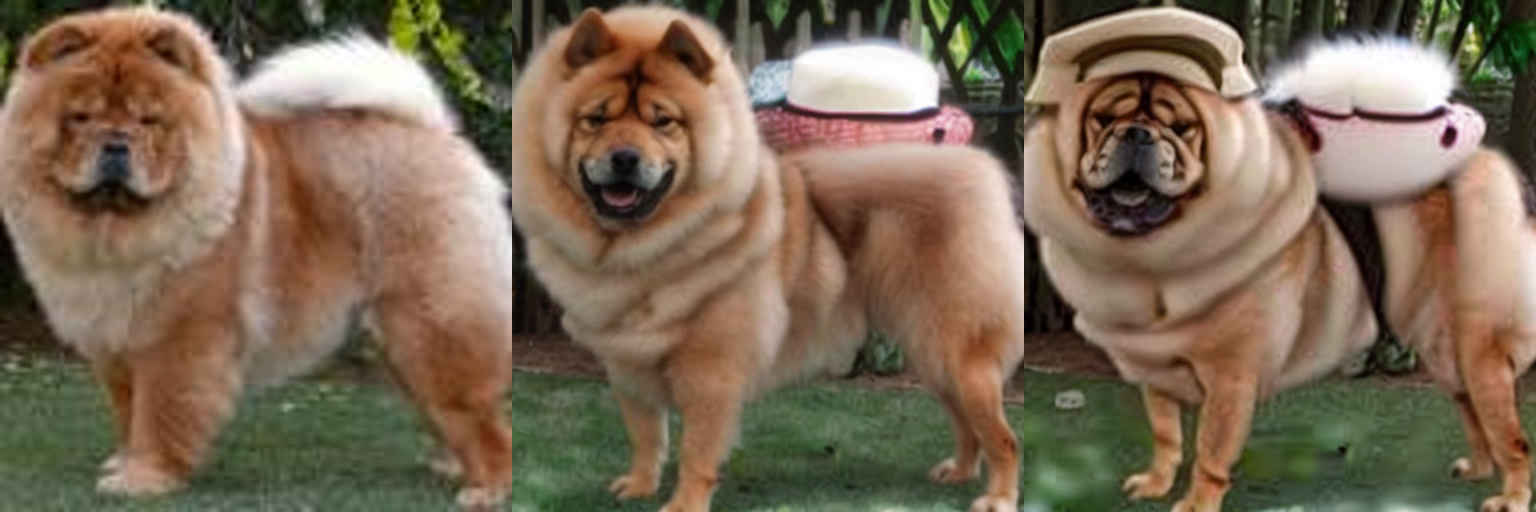

In [ ]:
lora_weights_path = f"{FULL_GDRIVE_SAVE_PATH}/chow_outputs/checkpoint-600"
image_to_edit_path = f"{FULL_GDRIVE_SAVE_PATH}/dreambooth_datasets/chow/chow3.jpg"
init_image = Image.open(image_to_edit_path).convert("RGB").resize((512, 512))

prompt = "An image of TOK chow wearing a hat"
strength = 0.6  # This is the SDEdit 'faithfulness' parameter (0.0 = no change, 1.0 = full redraw)
num_inference_steps = 50
seed = 42

# LOAD ORIGINAL PIPELINE
print("🚀 Loading base SDEdit pipeline...")
base_pipe = StableDiffusionImg2ImgPipeline.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5").to("cuda")

# LOAD LORA PIPELINE
print("🎨 Loading LoRA-tuned SDEdit pipeline...")
lora_pipe = StableDiffusionImg2ImgPipeline.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5").to("cuda")
lora_pipe.load_lora_weights(lora_weights_path, weight_name="pytorch_lora_weights.safetensors")


# RUN INFERENCE (SDEdit) Original
generator = torch.Generator("cuda").manual_seed(seed) # Reset random seed generator for consistency, this ensures the generation uses the same seeds
print("⏳ Running SDEdit on Original Model...")
image_original = base_pipe(prompt=prompt, image=init_image, strength=strength, num_inference_steps=num_inference_steps, generator=generator).images[0]

# RUN INFERENCE (SDEdit) DreamBooth
generator = torch.Generator("cuda").manual_seed(seed) # Reset random seed generator for consistency, this ensures the generation uses the same seeds
print("⏳ Running SDEdit on LoRA Model...")
image_lora = lora_pipe(prompt=prompt, image=init_image, strength=strength, num_inference_steps=num_inference_steps, generator=generator).images[0]


# DISPLAY RESULTS
comparison = Image.new('RGB', (1536, 512))
comparison.paste(init_image, (0, 0))
comparison.paste(image_original, (512, 0))
comparison.paste(image_lora, (1024, 0))

print("\nResults Order: [Input Image] | [Original Model SDEdit] | [LoRA Model SDEdit]")
display(comparison)

# Forensics Challenge (Membership Inference)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


Analyzing 6 images...
  a.png: Mean MSE = 0.020465
  b.png: Mean MSE = 0.009476
  c.png: Mean MSE = 0.018671
  d.png: Mean MSE = 0.014402
  e.png: Mean MSE = 0.009466
  f.png: Mean MSE = 0.005548


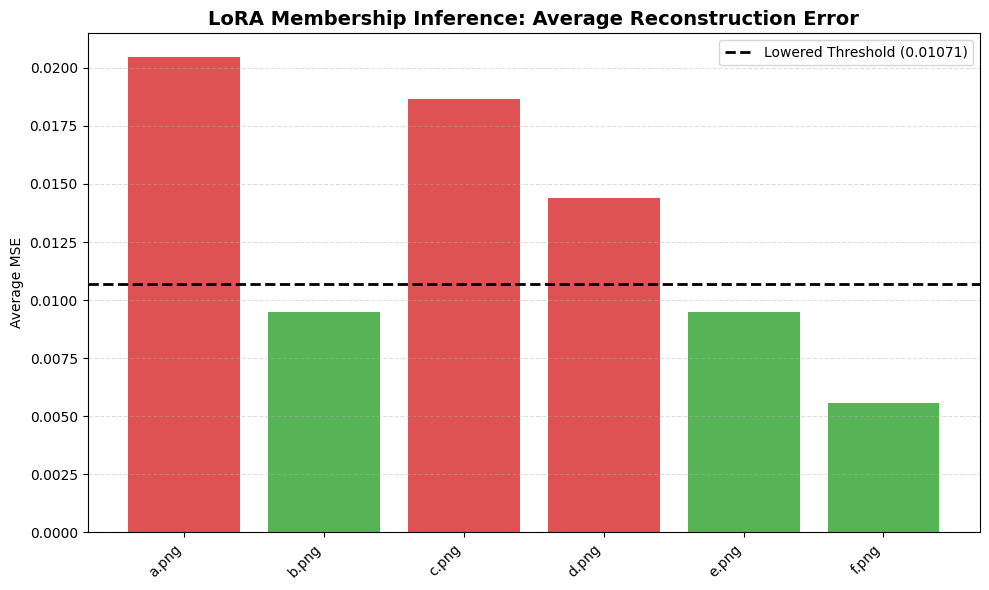


Lowered Decision Boundary: 0.010707
-------------------------------------------------------
IMAGE FILENAME            | MEAN MSE   | STATUS
-------------------------------------------------------
a.png                     | 0.020465   | ❌ UNSEEN
b.png                     | 0.009476   | ✅ IN TRAINING
c.png                     | 0.018671   | ❌ UNSEEN
d.png                     | 0.014402   | ❌ UNSEEN
e.png                     | 0.009466   | ✅ IN TRAINING
f.png                     | 0.005548   | ✅ IN TRAINING


In [16]:
import os
from glob import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from diffusers import StableDiffusionImg2ImgPipeline
from diffusers.utils import load_image

# --- 1. UTILITIES & VISUALIZATION ---

class ForensicsVisualizer:
    """Handles professional plotting for Membership Inference results."""

    @staticmethod
    def generate_analysis_dashboard(mean_scores, decision_threshold):
        """Creates a professional bar chart for classification."""
        plt.style.use('seaborn-v0_8-muted')
        plt.figure(figsize=(10, 6))

        filenames = list(mean_scores.keys())
        values = list(mean_scores.values())

        # Color bars based on membership inference
        colors = ['#2ca02c' if v <= decision_threshold else '#d62728' for v in values]

        plt.bar(filenames, values, color=colors, alpha=0.8)
        plt.axhline(y=decision_threshold, color="black", linestyle="--", linewidth=2,
                    label=f"Lowered Threshold ({decision_threshold:.5f})")

        plt.title("LoRA Membership Inference: Average Reconstruction Error", fontsize=14, fontweight='bold')
        plt.ylabel("Average MSE")
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.4)
        plt.legend()

        plt.tight_layout()
        plt.show()

def calculate_mse(img_a, img_b):
    arr_a = np.array(img_a).astype(np.float32) / 255.0
    arr_b = np.array(img_b).astype(np.float32) / 255.0
    return np.mean((arr_a - arr_b) ** 2)

# --- 2. CONFIGURATION & EXPERIMENT ---

LORA_PATH = f"{FULL_GDRIVE_SAVE_PATH}/ex5_forensics_supplementary/checkpoint-1500"
IMAGE_DIR = f"{FULL_GDRIVE_SAVE_PATH}/ex5_forensics_supplementary/*.png"
TARGET_PROMPT = "a photo of TOK person"
STRENGTH_LEVELS = [0.15, 0.25, 0.35, 0.45]

# Setup Pipeline
device = "cuda" if torch.cuda.is_available() else "cpu"
pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
).to(device)
pipe.load_lora_weights(LORA_PATH, weight_name="pytorch_lora_weights.safetensors")
pipe.set_progress_bar_config(disable=True)

# Run Inference
image_files = sorted(glob(IMAGE_DIR))
analysis_data = {}

print(f"Analyzing {len(image_files)} images...")
for img_path in image_files:
    fname = os.path.basename(img_path)
    base_img = load_image(img_path).convert("RGB").resize((512, 512))

    mses = []
    for s in STRENGTH_LEVELS:
        gen = torch.Generator(device).manual_seed(42)
        recon = pipe(prompt=TARGET_PROMPT, image=base_img, strength=s,
                     generator=gen, num_inference_steps=30).images[0]
        mses.append(calculate_mse(base_img, recon))

    analysis_data[fname] = mses
    print(f"  {fname}: Mean MSE = {np.mean(mses):.6f}")

# --- 3. ADJUSTED THRESHOLD & RESULTS ---

avg_mses = {name: np.mean(scores) for name, scores in analysis_data.items()}
sorted_scores = sorted(avg_mses.values())

# Threshold at 25% of the gap (stricter for training set classification)
gap_lower = sorted_scores[2]
gap_upper = sorted_scores[3]
adjusted_boundary = gap_lower + (gap_upper - gap_lower) * 0.25

# Final Visualization
visualizer = ForensicsVisualizer()
visualizer.generate_analysis_dashboard(avg_mses, adjusted_boundary)

print(f"\nLowered Decision Boundary: {adjusted_boundary:.6f}")
print("-" * 55)
print(f"{'IMAGE FILENAME':<25} | {'MEAN MSE':<10} | {'STATUS'}")
print("-" * 55)
for name, score in avg_mses.items():
    status = "✅ IN TRAINING" if score <= adjusted_boundary else "❌ UNSEEN"
    print(f"{name:<25} | {score:.6f}   | {status}")